In [5]:
import pandas as pd

races_df = pd.read_csv('races.csv')
results_df = pd.read_csv('results.csv')
drivers_df = pd.read_csv('drivers.csv')
constructors_df = pd.read_csv('constructors.csv')

In [6]:
print("Races DataFrame:")
print(races_df.head())

print("\nResults DataFrame:")
print(results_df.head())

print("\nDrivers DataFrame:")
print(drivers_df.head())

print("\nConstructors DataFrame:")
print(constructors_df.head())

Races DataFrame:
   raceId  year  round  circuitId                   name        date  \
0       1  2009      1          1  Australian Grand Prix  2009-03-29   
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05   
2       3  2009      3         17     Chinese Grand Prix  2009-04-19   
3       4  2009      4          3     Bahrain Grand Prix  2009-04-26   
4       5  2009      5          4     Spanish Grand Prix  2009-05-10   

       time                                                url fp1_date  \
0  06:00:00  http://en.wikipedia.org/wiki/2009_Australian_G...       \N   
1  09:00:00  http://en.wikipedia.org/wiki/2009_Malaysian_Gr...       \N   
2  07:00:00  http://en.wikipedia.org/wiki/2009_Chinese_Gran...       \N   
3  12:00:00  http://en.wikipedia.org/wiki/2009_Bahrain_Gran...       \N   
4  12:00:00  http://en.wikipedia.org/wiki/2009_Spanish_Gran...       \N   

  fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time  \
0       \N       \N       \

In [7]:
df = pd.merge(results_df, races_df, on='raceId')

In [8]:
df = pd.merge(df, drivers_df, on='driverId')

In [9]:
df = pd.merge(df, constructors_df, on='constructorId')

In [10]:
import numpy as np

df.replace(r'\N', np.nan, inplace=True)

In [11]:
df['position'] = pd.to_numeric(df['position'])
df['points'] = pd.to_numeric(df['points'])
df['laps'] = pd.to_numeric(df['laps'])

In [12]:
df['points'].fillna(0, inplace=True)

/tmp/ipython-input-3792628425.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['points'].fillna(0, inplace=True)


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

/tmp/ipython-input-1224590154.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_drivers, x='wins', y='driverRef', palette='viridis')


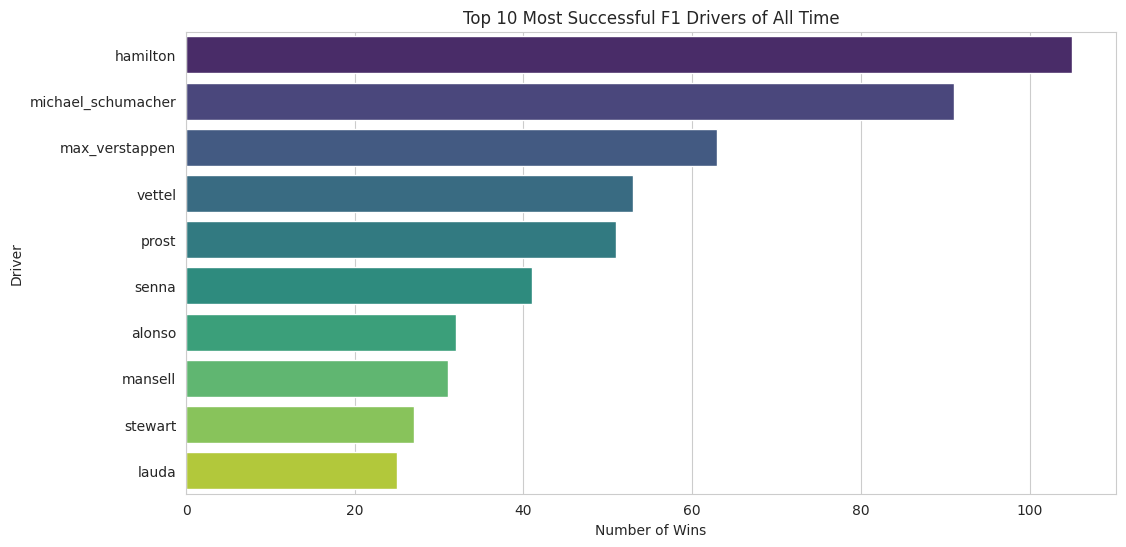

In [14]:
winners_df = df[df['position'] == 1]

driver_wins = winners_df.groupby(['driverRef', 'forename', 'surname']).size().reset_index(name='wins')

top_10_drivers = driver_wins.sort_values(by='wins', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_drivers, x='wins', y='driverRef', palette='viridis')

plt.title('Top 10 Most Successful F1 Drivers of All Time')
plt.xlabel('Number of Wins')
plt.ylabel('Driver')
plt.show()

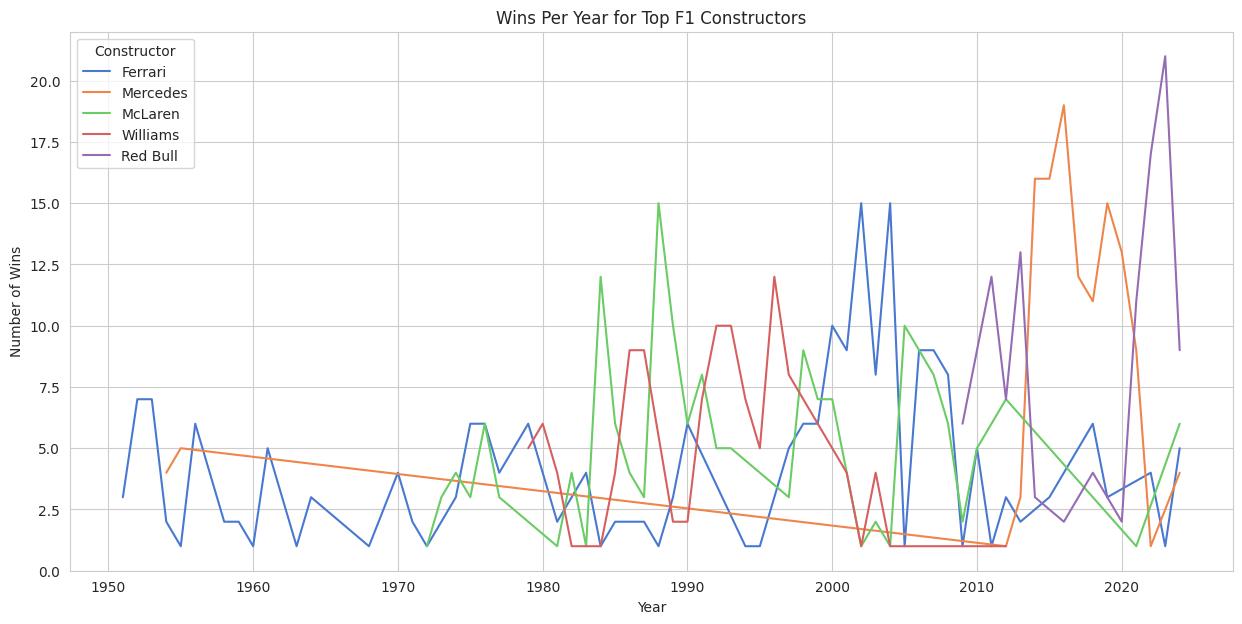

In [15]:
constructor_wins_df = df[df['position'] == 1]

wins_per_year = constructor_wins_df.groupby(['year', 'name_y']).size().reset_index(name='wins')

top_constructors = wins_per_year.groupby('name_y')['wins'].sum().nlargest(5).index

top_teams_wins_per_year = wins_per_year[wins_per_year['name_y'].isin(top_constructors)]

plt.figure(figsize=(15, 7))
sns.lineplot(data=top_teams_wins_per_year, x='year', y='wins', hue='name_y', palette='muted')

plt.title('Wins Per Year for Top F1 Constructors')
plt.xlabel('Year')
plt.ylabel('Number of Wins')
plt.legend(title='Constructor')
plt.show()

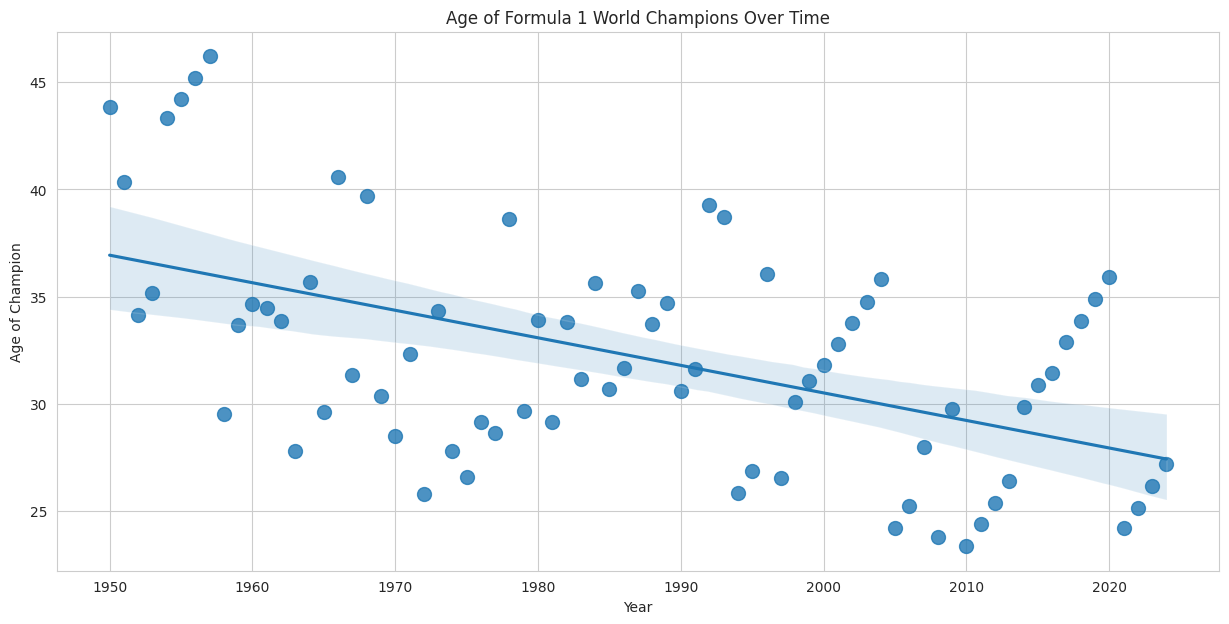

In [16]:
# First, ensure date columns are in datetime format
df['date'] = pd.to_datetime(df['date'])
df['dob'] = pd.to_datetime(df['dob'])

# Calculate driver points per season
driver_standings = df.groupby(['year', 'driverRef', 'dob'])['points'].sum().reset_index()

# Find the champion for each year (driver with max points)
champions = driver_standings.loc[driver_standings.groupby('year')['points'].idxmax()]

# Get the date of the last race for each season
season_end_dates = df.groupby('year')['date'].max().reset_index()

# Merge to get the date the championship was effectively won
champions = pd.merge(champions, season_end_dates, on='year')

# Calculate the champion's age at the end of the season
champions['age'] = (champions['date'] - champions['dob']).dt.days / 365.25

# plot
plt.figure(figsize=(15, 7))
sns.regplot(data=champions, x='year', y='age', scatter_kws={'s':100})

plt.title('Age of Formula 1 World Champions Over Time')
plt.xlabel('Year')
plt.ylabel('Age of Champion')
plt.show()

/tmp/ipython-input-202855400.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nationality_counts.index, y=nationality_counts.values, palette='cubehelix')


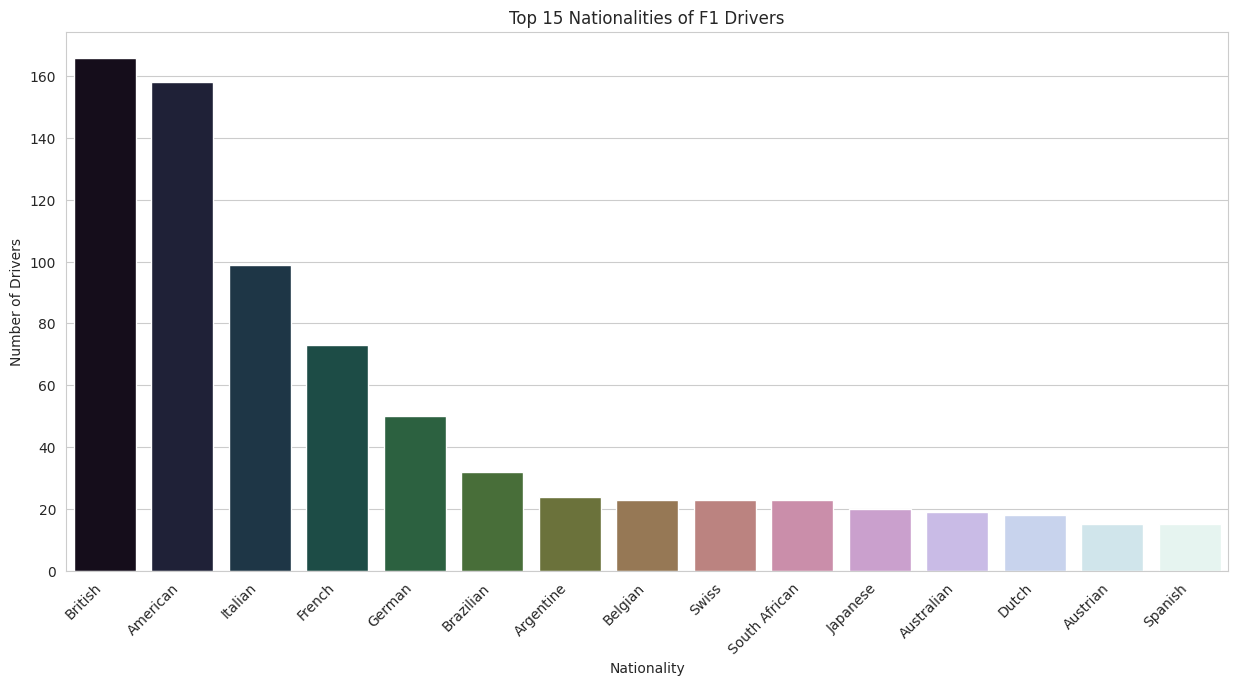

In [17]:
nationality_counts = drivers_df['nationality'].value_counts().head(15)

plt.figure(figsize=(15, 7))
sns.barplot(x=nationality_counts.index, y=nationality_counts.values, palette='cubehelix')

plt.title('Top 15 Nationalities of F1 Drivers')
plt.xlabel('Nationality')
plt.ylabel('Number of Drivers')
plt.xticks(rotation=45, ha='right')
plt.show()